# Laboratorio de regresión - 2

## Significancia de factores

Descarga el archivo de publicidad y carga los datos (Advertising.csv).

In [94]:
import pandas as pd

df = pd.read_csv('Datasets/Advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


**¿Hay alguna relación entre el presupuesto para publicidad y las ventas?**

Nuestra primera meta debe ser determinar si hay evidencia en los datos de que haya una asociación entre estas variables.

- ¿Por qué? ¿Qué resultaría si nos diéramos cuenta de la falta de relación entre el presupuesto de publicidad y las ventas?

Si no existiera esta relación postiva es innecesario hacer un gasto en la publicidad para el incremento de ventas.

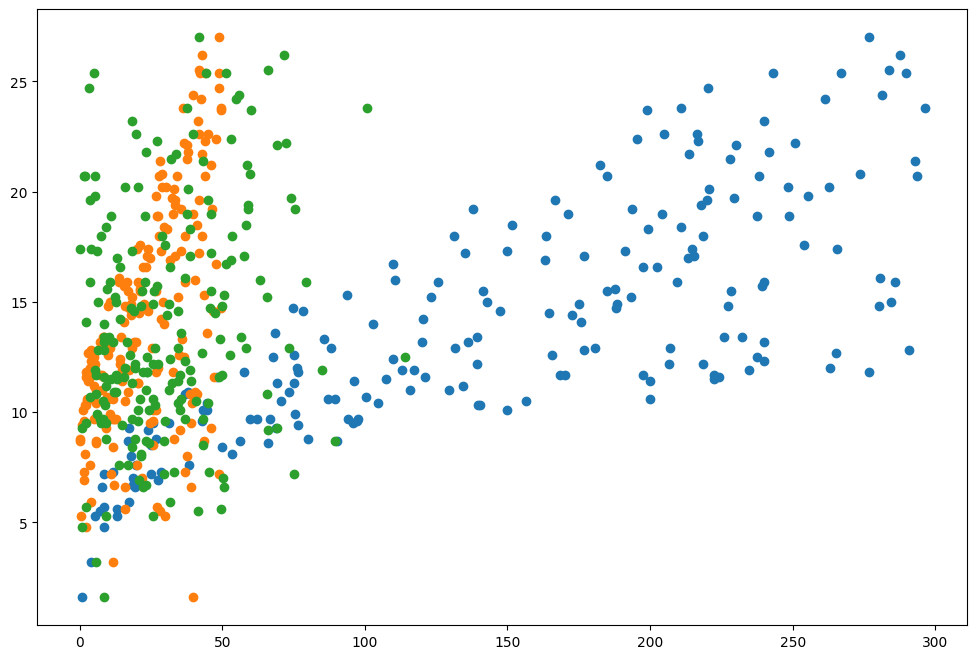

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(12, 8))
plt.scatter(df['TV'], df['sales'])
plt.scatter(df['radio'], df['sales'])
plt.scatter(df['newspaper'], df['sales'])
plt.show()

**¿Qué tan fuerte es esta relación?**
Asumiendo que existe esta relación, ¿nos sirve conocer el impacto que tiene invertir en publicidad en las ventas?

Si nos sirve ya que nos permitiria ajustar presupuestos óptimos en los medios asociados para máximizar las ganancias, este impacto nos permitiría saber que tanto beneficia invertir en publicidad.

**¿Cuáles medios están asociados con las ventas? ¿Qué tan grande es la asociación entre un medio específico y las ventas?**

Hay 3 medios distintos en los datos. ¿Sirve invertir en los 3? ¿Conviene más invertir sólo en uno?

**¿Qué tan seguros estamos de que podríamos predecir ventas futuras?**

**¿La relación es lineal?**

**¿Hay sinergia entre estos medios?**

Puede ser que gastar \\$50,000 en publicidad y otros \\$50,000 en radio es mejor opción que gastar \\$100,000 en televisión. A esto le llamamos efecto de interacción.

Podemos usar regresión lineal para responder todas estas preguntas.

Realiza una regresión lineal:

$$ \text{ventas} \approx \beta_0 + (\beta_1)(\text{TV})$$

### Regresión TV-Sales

[7.03259355] [[0.04753664]]


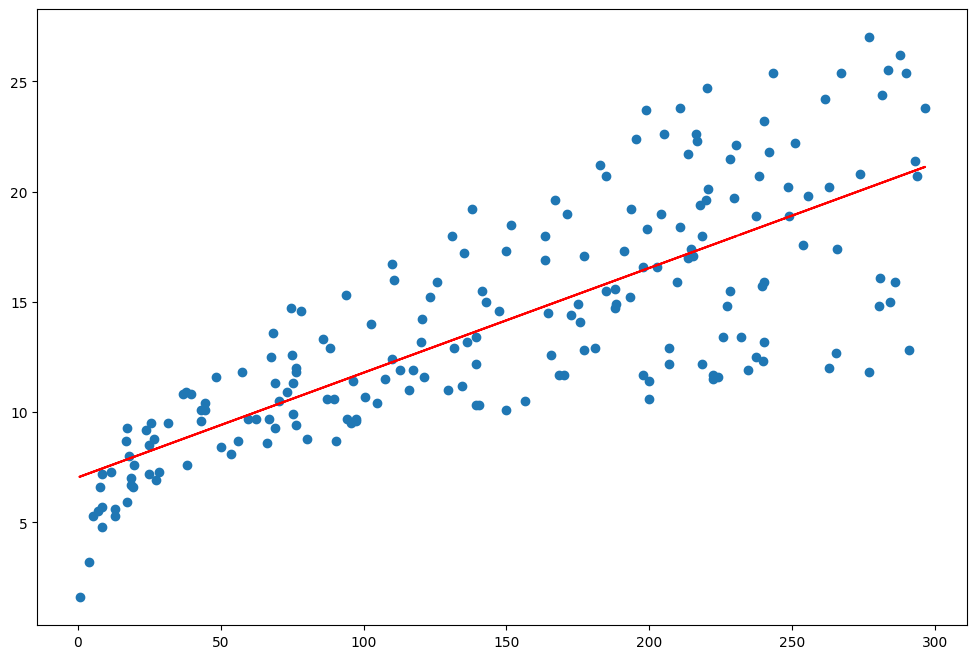

In [96]:
lr = LinearRegression()
x1_tv = df['TV'].values
arr1 = np.reshape(x1_tv, [-1,1])
y = np.reshape(df['sales'], [-1,1])

lr.fit(arr1, y)
y_tv_pred = lr.predict(arr1)
print(lr.intercept_, lr.coef_)
plt.figure(figsize=(12, 8))
plt.scatter(df['TV'], df['sales'])
plt.plot(df['TV'], y_tv_pred, color='red')
plt.show()


### Verificando la precisión de nuestros coeficientes estimados

Recuerda que en el mundo real hay ruidos y errores de medición. Siempre se asume que la verdadera relación entre $X$ y $Y$ es $$Y = \beta_0 + \beta_1 X + \epsilon$$

Se asume que el término de error es independiente de $X$ (el error siempre es el mismo sin importar el valor de $X$). Este modelo describe a la *línea de regresión de la población*, que es la mejor aproximación de la verdadera relación entre $X$ y $Y$. Cuando usamos mínimos cuadrados encontramos la *línea de mínimos cuadrados*.

¿Cuál es la diferencia entre población y muestra?

**Población se refiere a todo nuestro conjunto total de los elementos a estudiar y la muestra es una parte seleccionada pequeña de este conjunto.**

¿Cuál crees que sea la diferencia entre hacer una regresión con todos los datos de la población y una muestra de ella?

**Realizar una regresión con todos los datos de la población nos encuentra los betas absolutos que describen la relación entre los elmentos de la población por lo tanto una regresión ajustada a esta población es la ideal mientras que hacer una regresión con una muestra de la población nos da coeficientes que estiman el comportamiento lineal de este, es decir no sabemos si son los betas que mejor describen a la población pero podemos inferirlo**

La línea de regresión de la población no se puede observar. El concepto de comparar estas líneas es una extensión natural del acercamiento estadístico estándar de usar información de una muestra para estimar características de una población grande.

Imagina que quieres encontrar la altura promedio de un mexicano $\mu$. Medir a todos y cada uno de los mexicanos en situaciones similares, con la misma regla, mismo operador, y otras incontables formas de minimizar la variación de la medida es una tarea imposible. Lo que podemos asumir es que $\hat{\mu} = \bar{y}$. La media poblacional y la media muestral son diferentes, pero la media muestral es usualmente un buen estimado.

De la misma manera, como no contamos con el 100% de la información para hacer una regresión, los coeficientes $\beta_0$ y $\beta_1$ son desconocidos. Podemos estimarlos usando mínimos cuadrados, encontrando $\hat{\beta_0}$ y $\hat{\beta_1}$. Puede que las muestras que tengamos en ese momento estén un poco por encima de la media, pero otras muestras en otro momento puede que estén debajo de la media. En general, esperamos que el promedio de las aproximaciones $\hat{\mu}$ aproxime a $\mu$.

Esto lleva a la pregunta: ¿qué tan cercanos son nuestros coeficientes estimados a los verdaderos coeficientes? Utilizamos el concepto de error estándar para evaluar esto.

$$ \text{Var}(\hat{\mu})=\text{SE}(\hat{\mu})^2 = \frac{\sigma^2}{n} $$

Donde $\sigma$ es la desviación estándar de cada una de las observaciones $y_i$ de $Y$. El error estándar nos dice la cantidad promedio que el estimado difiere del valor verdadero. Podemos ver en la fórmula que entre más observaciones tengamos el error se hace más pequeño. Las fórmulas para errores estándar de $\hat{\beta_0}$ y $\hat{\beta_1}$ son:

$$ \text{SE}(\hat{\beta_0})^2 = \sigma^2 [\frac{1}{n} + \frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2}]$$

$$ \text{SE}(\hat{\beta_1})^2 = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2}$$

$$ \sigma^2 = \text{Var}(\epsilon) = \text{RSE}^2 = \frac{\text{RSS}}{n-p}$$

Para que estas fórmulas sean validas asumimos que los errores $\epsilon_i$ tienen varianza común $\sigma^2$ y que no están correlacionados.

Calcula los errores estándar de los coeficientes

In [97]:
sigma_2 = np.sum((y - y_tv_pred)**2) / (len(y) - 2)
SE_B1 = np.sqrt(sigma_2/(np.sum((arr1-arr1.mean())**2)))
SE_B0 = np.sqrt(sigma_2*((1/len(arr1))+((arr1.mean()**2)/np.sum((arr1-arr1.mean())**2))))

Estos errores se pueden usar para calcular intervalos de confianza. Un intervalo de confianza del $95\%$ se define como un rango de valores en el cuál se encuentra el desconocido valor verdadero con un $95\%$ de probabilidad.

Otra forma de verlo es que si tomamos muestras repetidas y construimos un intervalo de confianza para cada una, el $95\%$ de los intervalos creados van a contener el valor verdadero. Para la regresión el intervalo de confianza del $95\%$ toma la forma:

$$ \hat{\beta_j} \pm 2\text{SE}(\hat{\beta_j})$$

Calcula los intervalos de confianza para los coeficientes estimados:

In [98]:
print(f'Intervalo para B0: {lr.intercept_ - 2*SE_B0} < B0 < {lr.intercept_ + 2*SE_B0}')
print(f'Intervalo para B1: {lr.coef_ - 2*SE_B1} < B1 < {lr.coef_ + 2*SE_B1}')

Intervalo para B0: [6.11690767] < B0 < [7.94827943]
Intervalo para B1: [[0.04215543]] < B1 < [[0.05291785]]


Los errores estándar también se usan para realizar pruebas de hipótesis. La prueba de hipótesis más común es probar la hipótesis nula de:

$$ H_0: \text{No hay relación entre } X \text{ y } Y \ \ \ \ (\beta_1=0)$$

contra la hipótesis alternativa:
$$ H_0: \text{Hay alguna relación entre } X \text{ y } Y \ \ \ (\beta_1 \neq 0)$$

Explica con tus palabras el significado de la hipótesis nula y la hipótesis alternativa.

**La hipótesis nula es la que esta por defecto en todas las pruebas estadísticas, es aquella que afirma que NO hay relación o efecto entre variables. La hipótesis alternativa es la que refuta la hipótesis nula, es el estudio que se intenta comprobar**

Para probar la hipótesis nula debemos determinar si nuestro estimado $\hat{\beta_1}$ de $\beta_1$ está lo suficientemente alejado de cero para que podamos decir con confianza que este valor no es cero. 

¿Qué tan lejos? Depende de qué tanta confianza tengamos en el estimado encontrado. Si nuestro error estándar es pequeño y nuestro estimado está alejado de cero podríamos decir que hay muy poca probabilidad de que el valor verdadero sea 0. En cambio, si nuestro error estándar es grande y nuestro estimado está muy cerca de cero, entonces podrías ser que el valor verdadero sea cero y que no haya relación entre las variables.

Se calcula un *estadístico t* dado por
$$ t = \frac{\hat{\beta_j} - \mu}{\text{SE}(\hat{\beta_j})} $$

donde $\mu$ es el valor contra el que queremos probar.

Calcula el estadístico t para tus coeficientes estimados, usando como referencia la prueba de hipótesis.

In [99]:
t_B0 = (lr.intercept_ - 0) / SE_B0
t_B1 = (lr.coef_ - 0) / SE_B1
print(f'T de B0: {t_B0}, T de B1: {t_B1}')

T de B0: [15.36027517], T de B1: [[17.6676256]]


La distribución t tiene forma de campana y se parece bastante a la distribución normal cuando $n > 30$. Ya sólo es cuestión de calcular la probabilidad de observar cualquier número tal que su valor absoluto sea igual o mayor que el valor absoluto del estadístico t calculado. En otras palabras:
$$ P(|x| \geq |t|) $$

A esta probabilidad la llamamos *p-value*. Un *p-value* pequeño indica que es poco probable que exista por puro azar una relación significativa entre predictor y respuesta, en caso de que no haya una asociación real entre predictor y respuesta. En otras palabras, el *p-value* te dice la probabilidad de que parezca que hay relación cuando no la hay.

Si el *p-value* es pequeño, inferimos que sí hay una asociación entre el predictor y la respuesta, y **rechazamos la hipótesis nula**.
  

¿Qué tan pequeño? Depende de la aplicación. Un valor muy común es del $5\%$.

Utiliza el siguiente código para calcular el *p-value* para tus coeficientes

`from scipy import stats`

`p_bj = 2*(1 - stats.t.cdf(np.abs(t_bj), n-p))`

In [100]:
from scipy import stats
p_b0 = 2*(1 - stats.t.cdf(np.abs(t_B0), len(arr1)-2))
p_b1 = 2*(1 - stats.t.cdf(np.abs(t_B1), len(arr1)-2))
print(f'P de B0: {p_b0}, P de B1: {p_b1}')

P de B0: [0.], P de B1: [[0.]]


¿Se rechaza la hipótesis nula? ¿Qué significa?

**Se rechaza la hipótesis nula, es poco probable que la relación entre TV y Sales sea por puro azar por lo tanto se infiere que B0 ES DIFERENTE de 0, ESTADÍSTICAMENTE si hay relación lineal entre TV y Sales**

Realiza otras dos regresiones. Ya tienes hecha la regresión de ventas dado el gasto en publicidad de TV. Realiza la regresión para gastos en radio y gastos en periódico. Organiza las respuestas para que debajo de esta celda se tenga:
- Título de regresión
- Coeficientes estimados
- Errores estándar de los coeficientes
- Intervalos de confianza
- Estadísticos t
- p-values
- Observaciones

### Regresión Radio-Sales

B0 = [9.3116381], B1 = [[0.20249578]]


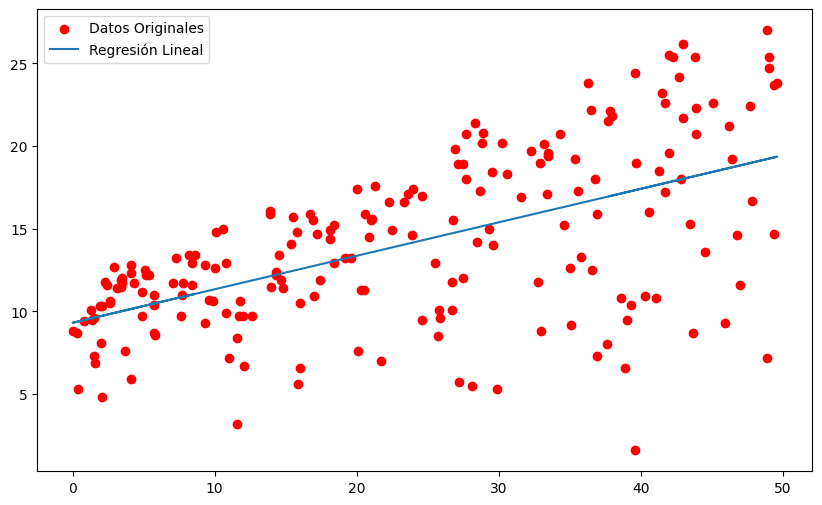

In [101]:
x1_radio = df['radio'].values
arr2 = np.reshape(x1_radio, [-1,1])
lr.fit(arr2,y)
y_radio_pred = lr.predict(arr2)
print(f'B0 = {lr.intercept_}, B1 = {lr.coef_}')

plt.figure(figsize=(10,6))
plt.scatter(arr2,y,label='Datos Originales', c='Red')
plt.plot(arr2, y_radio_pred, label = 'Regresión Lineal')
plt.legend()
plt.show()

In [102]:
RSSr = np.sum((y-y_radio_pred)**2)
sigma_2r = RSSr/(len(y)-2)
SE_B0r = np.sqrt(sigma_2r*(1/(len(arr2) + arr2.mean()**2/np.sum((arr2-arr2.mean())**2))))
SE_B1r = np.sqrt(sigma_2r/(np.sum((arr2-arr2.mean())**2)))

print(f'SE_B0 = {SE_B0r}, SE_B1 = {SE_B1r}')


SE_B0 = 0.3022748906288282, SE_B1 = 0.020411306360090635


In [103]:
print(f'Intervalo de Confianza para B0: {lr.intercept_ - 2*SE_B0r} < B0 < {lr.intercept_ + 2*SE_B0r}')
print(f'Intervalo de Confianza para B1: {lr.coef_[0] - 2*SE_B1r} < B1 < {lr.coef_[0] + 2*SE_B1r}')

Intervalo de Confianza para B0: [8.70708831] < B0 < [9.91618788]
Intervalo de Confianza para B1: [0.16167317] < B1 < [0.2433184]


In [104]:
t_B0r = (lr.intercept_ - 0) / SE_B0r
t_B1r = (lr.coef_[0] - 0) / SE_B1r
print(f'Estadístico t para B0: {t_B0r}')
print(f'Estadístico t para B1: {t_B1r}')

Estadístico t para B0: [30.80519879]
Estadístico t para B1: [9.92076547]


In [105]:
pval_b0r = 2*(1 - stats.t.cdf(np.abs(t_B0r), len(arr2)-2))
pval_b1r = 2*(1 - stats.t.cdf(np.abs(t_B1r), len(arr2)-2))
print(f'P-valor para B0: {pval_b0r}')
print(f'P-valor para B1: {pval_b1r}')

P-valor para B0: [0.]
P-valor para B1: [0.]


ESTADÍSTICAMENTE los coeficientes son diferentes de 0 por lo tanto se INFIERE que si hay relación entre la publicidad de redio y las ventas.

### Regresión Newspapper-Sales

B0 = [12.35140707], B1 = [0.0546931]


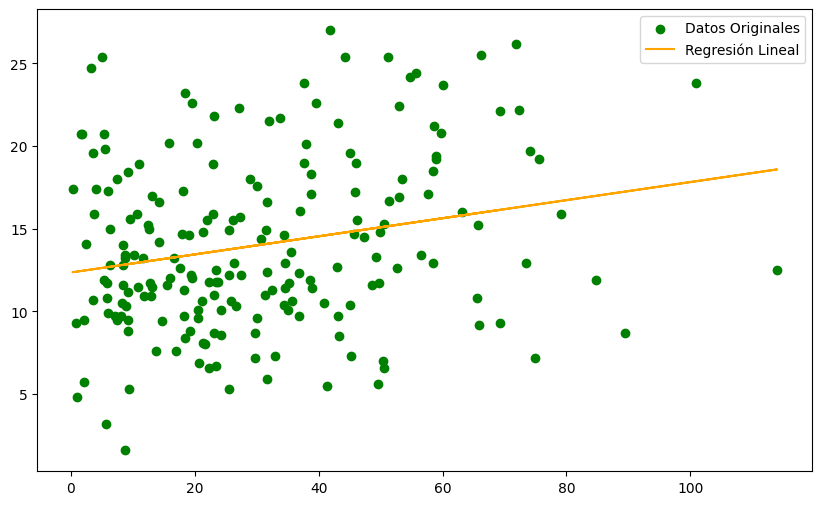

In [106]:
x1_n = df['newspaper'].values
arr3 = np.reshape(x1_n, [-1,1])
lr.fit(arr3,y)
y_n_pred = lr.predict(arr3)
print(f'B0 = {lr.intercept_}, B1 = {lr.coef_[0]}')

plt.figure(figsize=(10,6))
plt.scatter(arr3,y,label='Datos Originales', c='Green')
plt.plot(arr3, y_n_pred, label = 'Regresión Lineal', c='Orange')
plt.legend()
plt.show()

In [107]:
sigma_2n = np.sum((y-y_n_pred)**2)/(len(y)-2)
SE_B0n = np.sqrt(sigma_2n*(1/len(arr3) + arr3.mean()**2/np.sum((arr3-arr3.mean())**2)))
SE_B1n = np.sqrt(sigma_2n/(np.sum((arr3-arr3.mean())**2)))

print(f'SE_B0 = {SE_B0n}, SE_B1 = {SE_B1n}')

SE_B0 = 0.6214201876094345, SE_B1 = 0.016575721876358165


In [108]:
print(f'Intervalo para B0: {lr.intercept_ - 2*SE_B0n} < B0 < {lr.intercept_ + 2*SE_B0n}')
print(f'Intervalo para B1: {lr.coef_[0] - 2*SE_B1n} < B1 < {lr.coef_[0] + 2*SE_B1n}')

Intervalo para B0: [11.10856669] < B0 < [13.59424744]
Intervalo para B1: [0.02154165] < B1 < [0.08784454]


In [109]:
t_B0r = (lr.intercept_ - 0) / SE_B0r
t_B1r = (lr.coef_[0] - 0) / SE_B1r
print(f'Estadístico t para B0: {t_B0r}')
print(f'Estadístico t para B1: {t_B1r}')

Estadístico t para B0: [40.86150538]
Estadístico t para B1: [2.67954914]


In [110]:
pval_b0r = 2*(1 - stats.t.cdf(np.abs(t_B0r), len(arr2)-2))
pval_b1r = 2*(1 - stats.t.cdf(np.abs(t_B1r), len(arr2)-2))
print(f'P-valor para B0: {pval_b0r}')
print(f'P-valor para B1: {pval_b1r}')

P-valor para B0: [0.]
P-valor para B1: [0.0079926]


ESTADÍSTICAMENTE los coeficientes son diferentes de 0 por lo tanto se INFIERE que si hay relación entre la publicidad en Newspapper y Sales.

## Regresión lineal múltiple

En lugar de hacer una regresión para cada factor independiente, quizás se puede extender el modelo para que tenga varios factores dentro:

$$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p + \epsilon $$

Para nuestro ejemplo de publicidad:

$$ \text{sales} = \beta_0 + \beta_1 (\text{TV}) + \beta_2 (\text{radio}) + \beta_3 (\text{newspaper}) + \epsilon $$

Utiliza la librería `statsmodels` para realizar la regresión. Por defecto la librería statsmodels no toma en cuenta el intercepto ($\beta_0$), por lo que se tendrá que agregar una columna de unos de tamaño *n* a la matriz X.

`import statsmodels.api as sm`

`ols = sm.OLS(Y, X)`

`results = ols.fit()`

`results.summary()`

In [111]:
import statsmodels.api as sm
Y = np.reshape(df['sales'], [-1,1])
ones = np.ones((len(df['TV']),1))
xt = np.reshape(df['TV'], [-1,1])
xr = np.reshape(df['radio'], [-1,1])
xn = np.reshape(df['newspaper'], [-1,1])
X = np.hstack((ones, xt, xr, xn))

ols = sm.OLS(Y, X)
results = ols.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.58e-96
Time:                        20:41:55   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.000       2.324       3.554
x1             0.0458      0.001     32.809      0.000       0.043       0.049
x2             0.1885      0.009     21.893      0.000       0.172       0.206
x3            -0.0010      0.006     -0.177      0.860      -0.013       0.011
==============================================================================
Omnibus:                       60.414   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              151.241
Skew:                          -1.327   Prob(JB):                     1.44e-33
Kurtosis:                       6.332   Cond. No.                         454.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

¿Qué diferencias puedes observar entre los *p-values* de una regresión múltiple y los encontrados en las regresiones simples? ¿Por qué crees que existen estas diferencias?

**La diferencia principal es que el coeficiente de Newspapper tiene un p-value > 0.05 por lo tanto se considera = 0, dando a decir que en el modelo múltiple el periodico no explica las ventas, yo sugiero que existen las diferencias porque al tomar en cuenta tres variables cada una hace un efecto en la otras a la hora de evaluar su relación con las ventas**

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3

## Addendum

Para calcular los *p-values* de los parámetros sin `statsmodels`:
1. Calcular RSS
2. Calcular RSE
3. `var_beta = np.linalg.inv(X.T @ X) * rse**2` (X con columna de intercepto)
4. `std_beta = np.sqrt(var_beta.diagonal())` El orden de los valores corresponde al orden de los factores en las columnas de la matriz $X$.
5. Calcular *estadístico t*
6. Calcular *p-value*